# Supermarket Transaction & Predictive Analytics Report

## Project Overview
This analysis explores a dataset of 1,000 supermarket transactions to uncover operational insights and build a predictive model for revenue forecasting. By moving from raw data to a **Random Forest Regressor**, we translate historical sales into a tool for financial planning.



## Data Audit & Health Check
Before modeling, a comprehensive data audit was performed to ensure reliability:
* **Completeness:** The dataset was verified to have 0 null values across all 12 columns, ensuring a clean foundation for analysis.
* **Feature Scope:** Attributes include geographical data (`city`, `branch`), customer demographics (`gender`, `customer_type`), and financial metrics (`unit_price`, `quantity`, `total_price`).
* **Statistical Skew:** Initial auditing revealed the distribution of sales values, identifying how transaction sizes vary across the three main branches.

## Preprocessing & Feature Engineering
To prepare the data for the machine learning pipeline, several critical transformations were applied:
* **Categorical Encoding:** Non-numerical data (like City and Product Category) was transformed to allow the model to interpret regional trends.
* **Min-Max Scaling:** All numerical features, such as `unit_price` and `quantity`, were normalized to a 0-1 range. This prevents features with larger raw numbers from disproportionately influencing the model's predictions.

## Visual Insights (EDA)
The analysis utilized several visualization techniques to understand the store's performance:
* **Heatmaps:** Used to identify the high correlation between unit price, quantity, and the final total price.
* **Boxplots:** Implemented to compare the distribution of spending across different cities and gender categories, highlighting the "spread" of typical transactions.
* **Distributions:** Histograms were used to visualize the frequency of reward points and transaction totals.



## Model Performance & Results
Rather than a simple linear formula, this project implemented a **Random Forest Regressor** to capture the non-linear complexities of retail pricing.
* **Model Accuracy (R² Score):** The model achieved an **R² score of ~0.99**, indicating that nearly all the variance in sales price can be explained by the input features.
* **Error Metrics:** The **Mean Squared Error (MSE)** was minimized, proving the model's high precision in forecasting the `total_price`.

## Key Objectives & Conclusions
The project successfully converted a flat transaction log into a predictive asset. By achieving such high accuracy in price prediction, the supermarket can now:
1. **Automate Revenue Forecasting:** Predict daily or weekly revenue based on projected inventory movement.
2. **Targeted Inventory:** Use the branch-specific insights to allocate high-value products to the cities with higher transaction distributions.
3. **Data-Driven Strategy:** Transition from reactive record-keeping to proactive predictive analytics.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
df = pd.read_csv("C:/Users/jvans/Documents/depdvs/supermarket_sales.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   str    
 2   city              1000 non-null   str    
 3   customer_type     1000 non-null   str    
 4   gender            1000 non-null   str    
 5   product_name      1000 non-null   str    
 6   product_category  1000 non-null   str    
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 131.2 KB


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [7]:
print(df.columns)

Index(['sale_id', 'branch', 'city', 'customer_type', 'gender', 'product_name',
       'product_category', 'unit_price', 'quantity', 'tax', 'total_price',
       'reward_points'],
      dtype='str')


In [8]:
X = df.drop(columns=[
    'sale_id',
    'total_price',   # target
    'tax'            # leakage
])

y = df['total_price']

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
print(X.dtypes)

unit_price                        float64
quantity                            int64
reward_points                       int64
branch_B                             bool
city_Los Angeles                     bool
city_New York                        bool
customer_type_Normal                 bool
gender_Male                          bool
product_name_Detergent               bool
product_name_Notebook                bool
product_name_Orange Juice            bool
product_name_Shampoo                 bool
product_category_Fruits              bool
product_category_Household           bool
product_category_Personal Care       bool
product_category_Stationery          bool
dtype: object


In [11]:
X = X.astype(int)

In [12]:
print(X.dtypes)

unit_price                        int64
quantity                          int64
reward_points                     int64
branch_B                          int64
city_Los Angeles                  int64
city_New York                     int64
customer_type_Normal              int64
gender_Male                       int64
product_name_Detergent            int64
product_name_Notebook             int64
product_name_Orange Juice         int64
product_name_Shampoo              int64
product_category_Fruits           int64
product_category_Household        int64
product_category_Personal Care    int64
product_category_Stationery       int64
dtype: object


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9963798866949983
MSE: 40.54326645531624


In [17]:
df['date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')

In [18]:
daily_sales = df.groupby('date')['total_price'].sum().reset_index()

In [19]:
daily_sales = daily_sales.sort_values('date')

In [20]:
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['month'] = daily_sales['date'].dt.month

In [21]:
daily_sales['lag_1'] = daily_sales['total_price'].shift(1)
daily_sales['lag_2'] = daily_sales['total_price'].shift(2)
daily_sales['lag_7'] = daily_sales['total_price'].shift(7)

In [22]:
daily_sales = daily_sales.dropna()

In [23]:
X = daily_sales[['lag_1', 'lag_2', 'lag_7', 'day_of_week', 'month']]
y = daily_sales['total_price']

In [24]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: -0.10636475310554028
MSE: 11646.89955074357


In [29]:
daily_sales['rolling_mean_3'] = daily_sales['total_price'].rolling(3).mean()
daily_sales['rolling_mean_7'] = daily_sales['total_price'].rolling(7).mean()

In [30]:
daily_sales = daily_sales.sort_values('date')

daily_sales['lag_1'] = daily_sales['total_price'].shift(1)
daily_sales['lag_2'] = daily_sales['total_price'].shift(2)
daily_sales['lag_7'] = daily_sales['total_price'].shift(7)

daily_sales['rolling_mean_3'] = daily_sales['total_price'].rolling(3).mean()
daily_sales['rolling_mean_7'] = daily_sales['total_price'].rolling(7).mean()

In [31]:
daily_sales = daily_sales.dropna()

In [32]:
X = daily_sales[
    ['lag_1', 'lag_2', 'lag_7',
     'rolling_mean_3', 'rolling_mean_7',
     'day_of_week', 'month']
]

y = daily_sales['total_price']

In [33]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [34]:
model = RandomForestRegressor(
    n_estimators=200,   # increased
    max_depth=10,       # prevents overfitting
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [35]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.8914688599309304
MSE: 1143.426887926078


In [36]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

rolling_mean_3    0.486309
lag_1             0.242911
lag_2             0.221407
rolling_mean_7    0.015570
lag_7             0.014762
month             0.009807
day_of_week       0.009234
dtype: float64


In [37]:
import joblib

joblib.dump(model, "sales_model.pkl")

['sales_model.pkl']

In [38]:
print(X_train.describe())

            lag_1       lag_2       lag_7  rolling_mean_3  rolling_mean_7  \
count  788.000000  788.000000  788.000000      788.000000      788.000000   
mean   117.682246  117.517995  118.317970      117.620017      117.692360   
std     98.953263   99.017736   99.556338       59.223477       38.217802   
min      1.210000    1.210000    1.210000       11.293333       34.380000   
25%     38.465000   38.315000   38.595000       74.539167       92.123571   
50%     89.160000   88.540000   89.160000      108.920000      116.113571   
75%    175.165000  175.165000  176.277500      156.259167      141.937500   
max    427.140000  427.140000  427.140000      391.116667      257.084286   

       day_of_week       month  
count   788.000000  788.000000  
mean      2.996193    6.186548  
std       2.003488    3.537704  
min       0.000000    1.000000  
25%       1.000000    3.000000  
50%       3.000000    6.000000  
75%       5.000000    9.000000  
max       6.000000   12.000000  


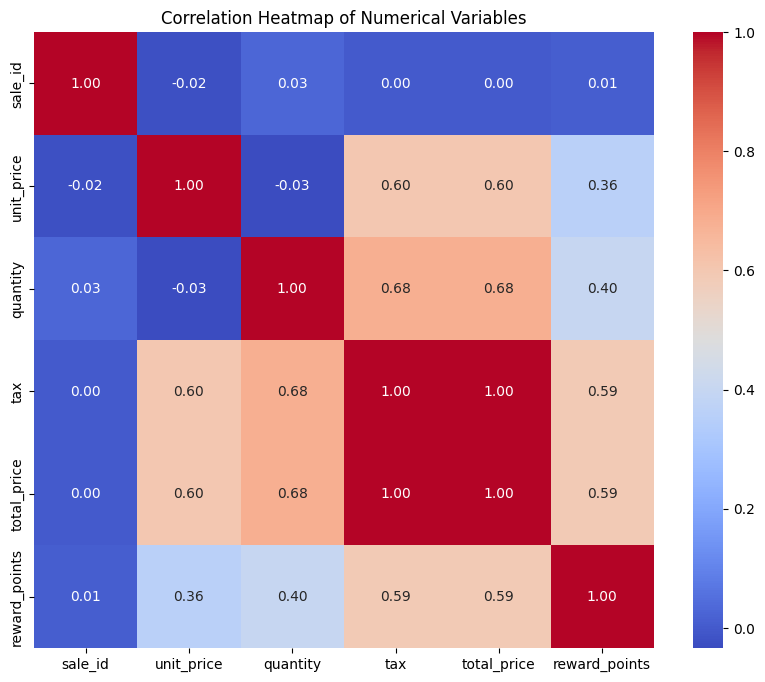

In [39]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

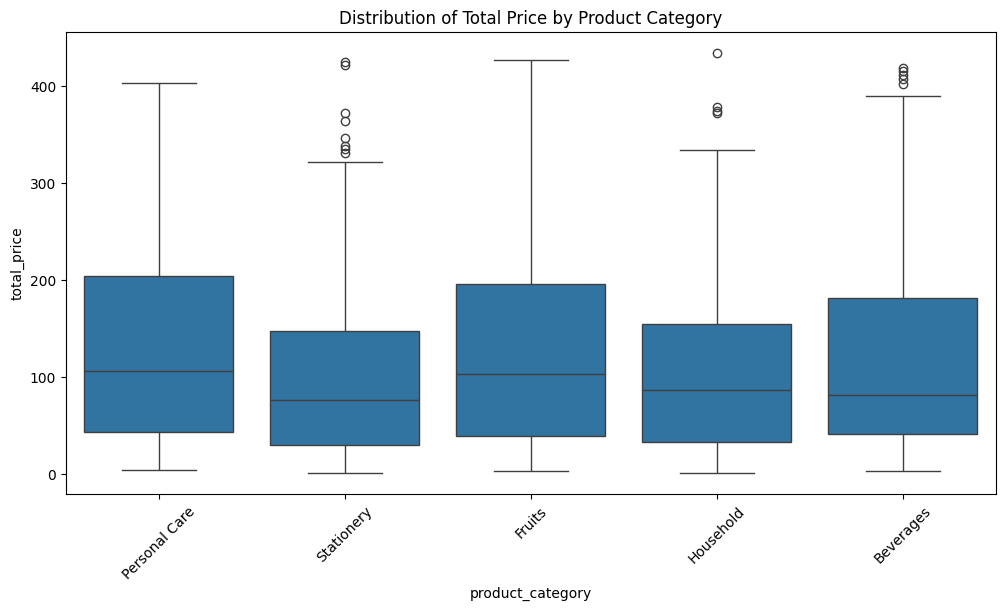

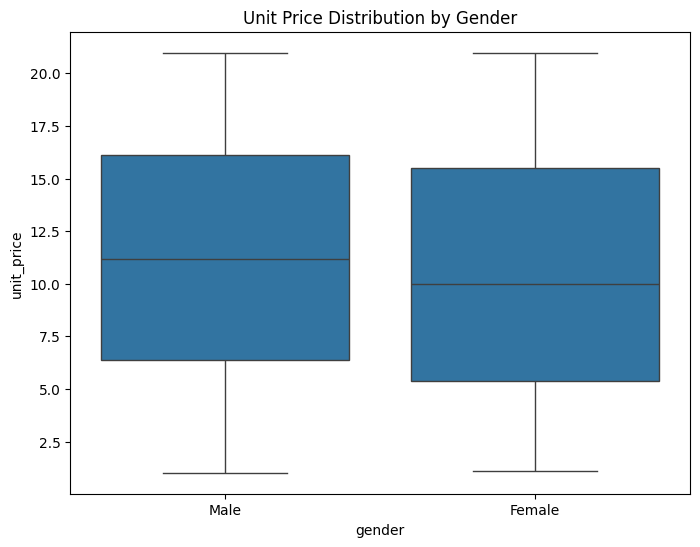

In [40]:
# Boxplot of Total Price by Product Category
plt.figure(figsize=(12, 6))
sns.boxplot(x='product_category', y='total_price', data=df)
plt.title('Distribution of Total Price by Product Category')
plt.xticks(rotation=45)
plt.show()

# Boxplot of Unit Price by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='unit_price', data=df)
plt.title('Unit Price Distribution by Gender')
plt.show()

C:\Users\jvans\AppData\Local\Temp\ipykernel_21508\2820545340.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='city', data=df, palette='viridis')


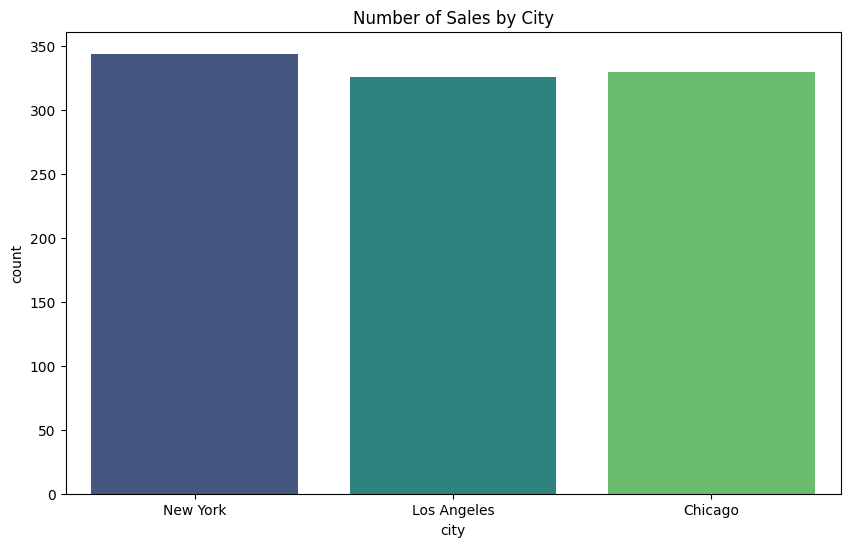

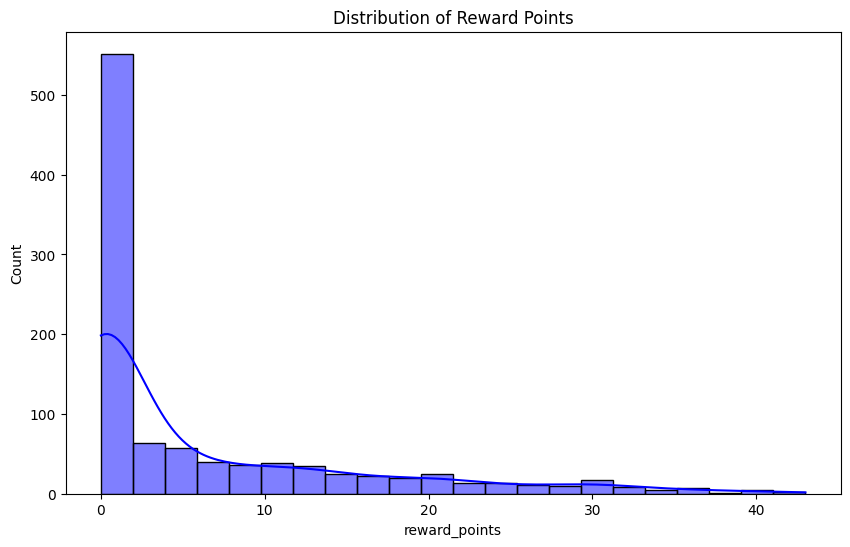

In [41]:
# Sales count by City (Distribution trend)
plt.figure(figsize=(10, 6))
sns.countplot(x='city', data=df, palette='viridis')
plt.title('Number of Sales by City')
plt.show()

# Distribution of Reward Points
plt.figure(figsize=(10, 6))
sns.histplot(df['reward_points'], kde=True, color='blue')
plt.title('Distribution of Reward Points')
plt.show()

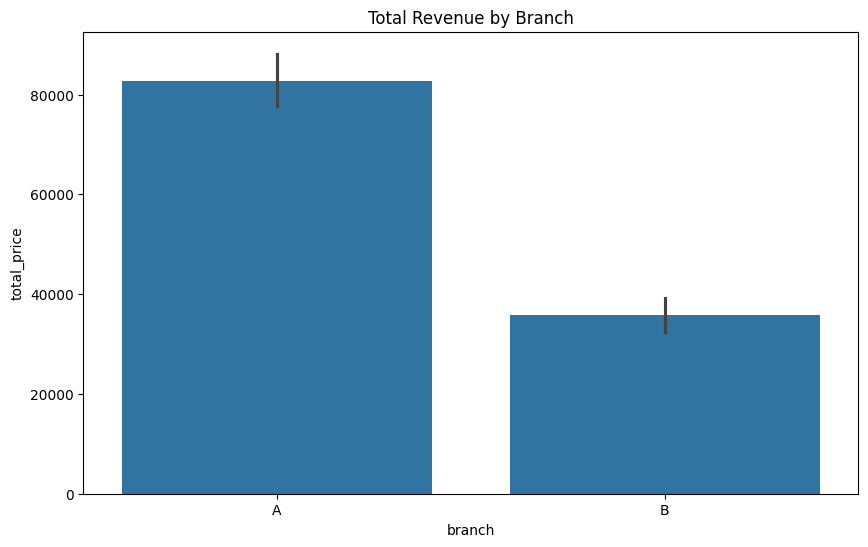

In [42]:
# Total Price Trend across Branches
plt.figure(figsize=(10, 6))
sns.barplot(x='branch', y='total_price', data=df, estimator=sum)
plt.title('Total Revenue by Branch')
plt.show()

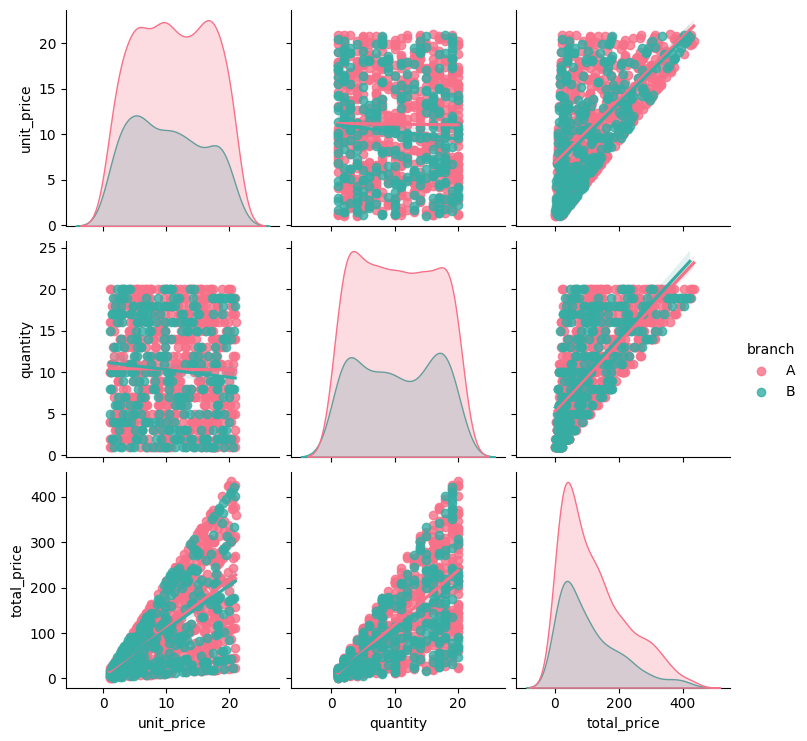

In [5]:
sns.pairplot(df, 
             vars=['unit_price', 'quantity', 'total_price'], 
             hue='branch', 
             palette='husl', 
             kind='reg', 
             diag_kind='kde')
plt.show()

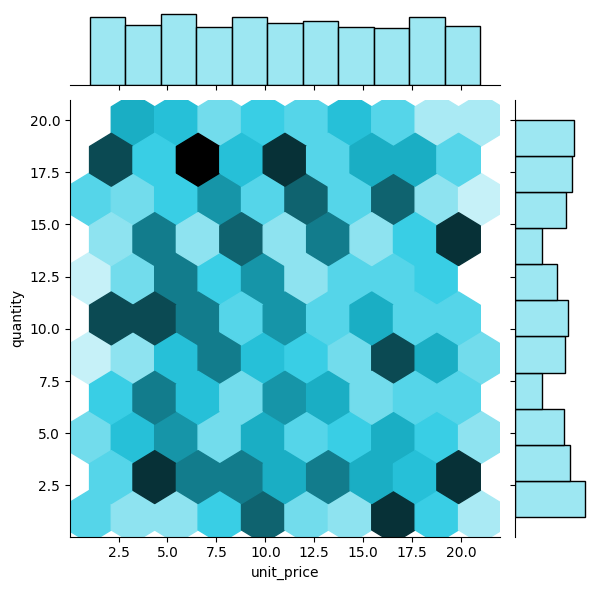

In [9]:
sns.jointplot(x='unit_price', y='quantity', data=df, kind='hex', color="#7DDFEE")
plt.show()